# TP Régression linéaire

**Prénom et nom : Hamadou BA**

# Exercice 1 - Régression linéaire univariée

Les données utilisées pour cet exercice décrivent les tailles d'enfants d'âge compris entre 2 et 8 ans : le fichier `ex1x.dat` correspond à leur âge et `ex1y.dat` correspond à leur taille (en mètres). On a dans ces 2 fichiers, les données de 50 enfants rangées dans le même ordre.

Ces données constituent des exemples d'apprentissage qui vont être utilisées afin de construire un modèle de régression linéaire qui a pour objectif de prédire la taille d'un enfant à partir de son âge.

### 1. Tout d'abord, nous allons utiliser la fonction `loadtxt` du package `numpy` en Python (ici désigné par `np`). Cette fonction permet de lire les fichiers et de les convertir en vecteurs/matrices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.loadtxt('ex1x.dat')
y = np.loadtxt('ex1y.dat')
m = len(x)
print(x.shape, y.shape)

(50,) (50,)


**Réponse :** on obtient deux vecteurs de 50 valeurs : les âges `x` et les tailles `y`.

### 2. Afficher le nuage de points $(x_i, y_i)$.

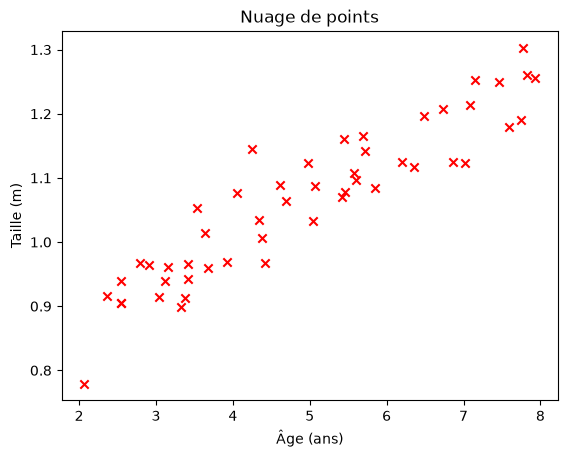

In [2]:
plt.scatter(x, y, c='r', marker='x')
plt.xlabel('Âge (ans)'); plt.ylabel('Taille (m)')
plt.title('Nuage de points')
plt.show()

**Réponse :** les points sont approximativement alignés le long d'une droite croissante : la taille augmente avec l'âge, un modèle linéaire est donc adapté.

### 3. Définir en Python la fonction hypothèse correspondant à un modèle de régression linéaire.
Soit le vecteur $\theta=(\theta_0,\theta_1)$, cette fonction hypothèse s'écrit $h(\theta_0,\theta_1,x)=\theta_0+\theta_1 x$.

In [3]:
def h(theta0, theta1, x):
    return theta0 + theta1 * x

### 4. Définir en Python la fonction de coût $J(\theta_0,\theta_1)$ telle que vue en cours.

In [4]:
def J(theta0, theta1):
    return np.sum((h(theta0, theta1, x) - y) ** 2) / (2 * m)

print('J(0, 0) =', J(0, 0))

J(0, 0) = 0.5737324907367211


**Réponse :** $J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^m (\theta_0+\theta_1 x_i-y_i)^2$ (critère des moindres carrés).

### 5. Définir en Python une fonction qui réalise une itération et renvoie $\theta_0^*$ et $\theta_1^*$ en fonction de $\theta_0$ et $\theta_1$, selon les formules de descente de gradient vues en cours.
Coefficient d'apprentissage constant $\alpha=0{,}07$, valeurs initiales $\theta_0=\theta_1=0$.

In [5]:
alpha = 0.07

def iteration(theta0, theta1):
    e = h(theta0, theta1, x) - y
    new0 = theta0 - alpha / m * np.sum(e)
    new1 = theta1 - alpha / m * np.sum(e * x)
    return new0, new1   # mise à jour simultanée

**Réponse :** $\theta_0^*=\theta_0-\frac{\alpha}{m}\sum_i (h_\theta(x_i)-y_i)$ et $\theta_1^*=\theta_1-\frac{\alpha}{m}\sum_i (h_\theta(x_i)-y_i)x_i$. Les deux paramètres sont mis à jour simultanément, avec les anciennes valeurs.

### 6. Faire tourner la méthode de descente de gradient sur quelques itérations puis représenter la droite $y=\theta_0+\theta_1 x$ sur le nuage de points.

theta0 = 0.09040986952034924  theta1 = 0.35100518836612754  J = 0.40573668261709966


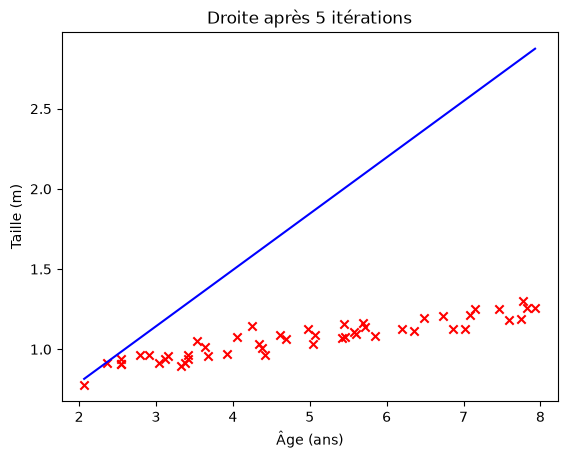

In [6]:
theta0, theta1 = 0.0, 0.0
for k in range(5):
    theta0, theta1 = iteration(theta0, theta1)
print('theta0 =', theta0, ' theta1 =', theta1, ' J =', J(theta0, theta1))

xs = np.linspace(x.min(), x.max(), 100)
plt.scatter(x, y, c='r', marker='x')
plt.plot(xs, h(theta0, theta1, xs), 'b')
plt.xlabel('Âge (ans)'); plt.ylabel('Taille (m)')
plt.title('Droite après 5 itérations'); plt.show()

**Réponse :** après 5 itérations la droite est encore trop pentue ($\theta_1\approx0{,}35$ au lieu de $\approx0{,}06$) et passe loin du nuage : $J$ est encore élevé (0,41) : l'algorithme n'a pas convergé.

### 7. Faire tourner la méthode de descente de gradient pendant toutes les itérations nécessaires à faire converger la solution $\theta$ recherchée.
Critère d'arrêt : $\left|\dfrac{J(\theta^*)-J(\theta)}{J(\theta)}\right|<\varepsilon$ ; on prend ici $\varepsilon=10^{-10}$ (valeur choisie plus petite que $10^{-3}$ pour obtenir une solution plus précise). Afficher la droite obtenue.

nombre d'itérations : 1512
theta0 = 0.7501514133540008  theta1 = 0.06388318963509147  J = 0.0009870699799372452


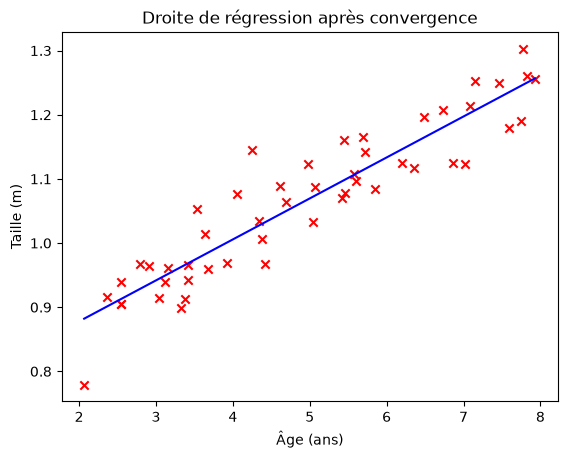

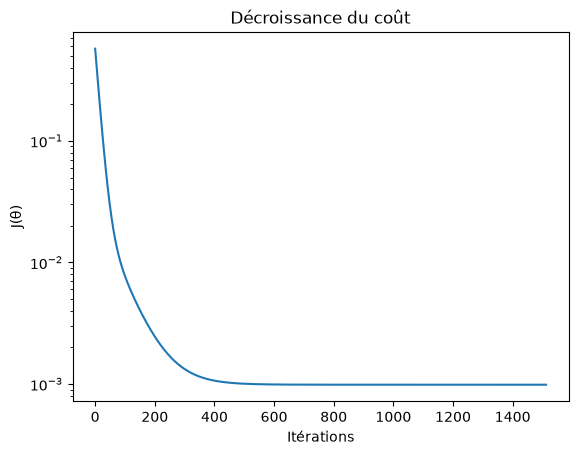

In [7]:
EPS = 1e-10  # seuil du critère d'arrêt
theta0, theta1 = 0.0, 0.0
n_iter = 0
hist = [J(theta0, theta1)]
while True:
    j_old = J(theta0, theta1)
    theta0, theta1 = iteration(theta0, theta1)
    j_new = J(theta0, theta1)
    hist.append(j_new)
    n_iter += 1
    if abs((j_new - j_old) / j_old) < EPS:
        break
print('nombre d\'itérations :', n_iter)
print('theta0 =', theta0, ' theta1 =', theta1, ' J =', j_new)

plt.scatter(x, y, c='r', marker='x')
plt.plot(xs, h(theta0, theta1, xs), 'b')
plt.xlabel('Âge (ans)'); plt.ylabel('Taille (m)')
plt.title('Droite de régression après convergence'); plt.show()

plt.plot(hist); plt.yscale('log')
plt.xlabel('Itérations'); plt.ylabel('J(θ)'); plt.title('Décroissance du coût'); plt.show()

**Réponse :** l'algorithme converge en 1512 itérations vers $\theta_0\approx0{,}750$ et $\theta_1\approx0{,}0639$ : à la naissance (âge 0) la taille extrapolée est d'environ 75 cm et l'enfant grandit d'environ 6,4 cm par an. La droite passe bien au milieu du nuage de points, et le coût $J$ décroît de façon monotone.

### 8. On peut désormais utiliser le modèle pour faire des prédictions : quelle est la taille de 3 enfants d'âges respectifs 3, 5 et 7 ans ?

In [8]:
for age in (3, 5, 7):
    print(f'Âge {age} ans -> taille prédite : {h(theta0, theta1, age):.3f} m')

Âge 3 ans -> taille prédite : 0.942 m
Âge 5 ans -> taille prédite : 1.070 m
Âge 7 ans -> taille prédite : 1.197 m


**Réponse :** environ **0,942 m** pour 3 ans, **1,070 m** pour 5 ans et **1,197 m** pour 7 ans.

### 9. Visualiser la fonction de coût $J(\theta)$ en 3D sur une grille de base 100 x 100, avec $\theta_0\in[-30;30]$ et $\theta_1\in[-3;3]$ (100 valeurs réparties dans ces intervalles).

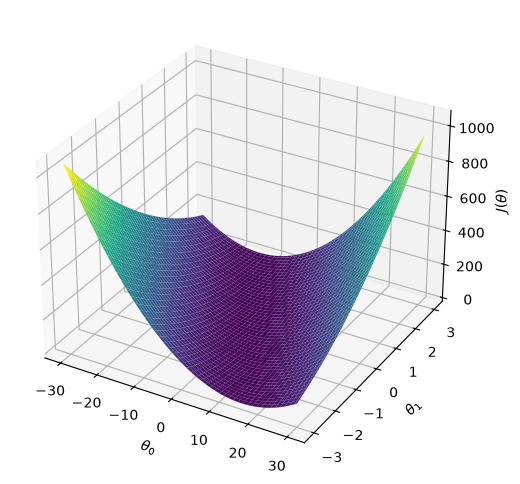

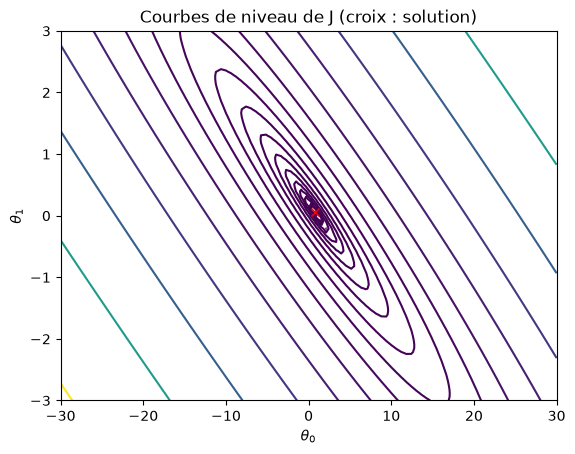

In [9]:
t0 = np.linspace(-30, 30, 100)
t1 = np.linspace(-3, 3, 100)
T0, T1 = np.meshgrid(t0, t1)
J_vals = np.array([[J(a, b) for a in t0] for b in t1])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis')
ax.set_xlabel(r'$\theta_0$'); ax.set_ylabel(r'$\theta_1$'); ax.set_zlabel(r'$J(\theta)$')
plt.show()

plt.contour(T0, T1, J_vals, levels=np.logspace(-2, 3, 20))
plt.plot(theta0, theta1, 'rx')
plt.xlabel(r'$\theta_0$'); plt.ylabel(r'$\theta_1$'); plt.title('Courbes de niveau de J (croix : solution)'); plt.show()

**Réponse :** $J$ est une surface en forme de cuvette (fonction convexe) avec un unique minimum, situé près de la solution trouvée (croix rouge sur les courbes de niveau). C'est ce qui garantit que la descente de gradient converge vers le minimum global. La vallée est très allongée selon $\theta_0$ : c'est pourquoi la convergence demande de nombreuses itérations.

# Exercice 2 - Régression linéaire multivariée et écriture matricielle de la méthode de descente du gradient

Dans ce problème, on utilise des données correspondant à 47 exemples d'apprentissage sur des données immobilières à Portland, Oregon (USA). Les données d'entrée $x$ (fichier `ex2x.dat`) correspondent aux surfaces et au nombre de pièces de ces 47 appartements et la donnée cible $y$ (fichier `ex2y.dat`) correspond au prix de ces mêmes appartements.

### 1. Utiliser la fonction `loadtxt` du package `numpy` pour lire les fichiers.

In [10]:
x2 = np.loadtxt('ex2x.dat')
y2 = np.loadtxt('ex2y.dat')
m2 = len(y2)
print(x2.shape, y2.shape)
print(x2[:3], y2[:3])

(47, 2) (47,)
[[2104.    3.]
 [1600.    3.]
 [2400.    3.]] [399900. 329900. 369000.]


**Réponse :** `x2` est une matrice 47×2 (surface, nombre de pièces) et `y2` un vecteur de 47 prix.

### 2. Prétraitement des données : utiliser `sklearn.preprocessing.StandardScaler` pour normaliser les données.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x2_norm = scaler.fit_transform(x2)
print('moyennes :', x2_norm.mean(axis=0))
print('écarts-types :', x2_norm.std(axis=0))

# matrice augmentée (colonne de 1) et vecteur cible
X = np.hstack([np.ones((m2, 1)), x2_norm])
Y = y2.reshape(-1, 1)
print(X.shape, Y.shape)

moyennes : [-9.44870659e-18  2.48028548e-16]
écarts-types : [1. 1.]
(47, 3) (47, 1)


**Réponse :** après centrage-réduction, chaque colonne a une moyenne nulle et un écart-type égal à 1. C'est nécessaire car la surface (de l'ordre de 2000) et le nombre de pièces (de l'ordre de 3) n'ont pas le même ordre de grandeur, ce qui ralentirait fortement la descente de gradient. On ajoute ensuite la colonne de 1 pour $\theta_0$.

### 3. Définir les fonctions en Python sous forme matricielle : l'hypothèse $h_\theta(X)$, le vecteur $E=h_\theta(X)-Y$, la fonction décrivant une itération et la fonction de coût $J(\theta)$.

In [12]:
def h_mat(theta, X):
    return X @ theta                      # h_theta(X) = X theta

def E(theta, X, Y):
    return h_mat(theta, X) - Y            # E = h_theta(X) - Y

def J2(theta, X=X, Y=Y):
    e = E(theta, X, Y)
    return (e.T @ e).item() / (2 * len(Y))   # J = E^T E / (2m)

def iteration2(theta, alpha, X=X, Y=Y):
    return theta - alpha / len(Y) * X.T @ E(theta, X, Y)   # theta* = theta - alpha/m X^T E

**Réponse :** $h_\theta(X)=X\theta$, $E=X\theta-Y$, $J(\theta)=\frac{1}{2m}E^TE$ et $\theta^*=\theta-\frac{\alpha}{m}X^TE$.

### 4. Pour la valeur du taux d'apprentissage $\alpha=0{,}07$, effectuer le calcul de régression permettant d'obtenir le vecteur $\theta=(\theta_0,\theta_1,\theta_2)$ optimal.
Critère d'arrêt : $\left|\frac{J(\theta^*)-J(\theta)}{J(\theta)}\right|<\varepsilon=10^{-10}$.

In [13]:
EPS = 1e-10  # seuil du critère d'arrêt

def descente(alpha, eps=EPS, max_iter=100000):
    theta = np.zeros((X.shape[1], 1))
    for k in range(max_iter):
        j_old = J2(theta)
        theta = iteration2(theta, alpha)
        if abs((J2(theta) - j_old) / j_old) < eps:
            break
    return theta, k + 1

theta, n = descente(0.07)
print('nombre d\'itérations :', n)
print('theta =', theta.ravel(), ' J =', J2(theta))

nombre d'itérations : 320
theta = [340412.65954651 109445.19339598  -6575.7517805 ]  J = 2043280053.584488


**Réponse :** la descente converge en 320 itérations vers $\theta\approx(340\,413;\ 109\,445;\ -6\,576)$. Ces paramètres sont exprimés pour des données normalisées : $\theta_0$ est le prix moyen, $\theta_1$ (surface) est très influent, $\theta_2$ (pièces) a un effet faible.

### 5. Recherche du meilleur taux d'apprentissage $\alpha\in[0{,}001;10]$
On calcule à chaque itération $J(\theta)$ (valeurs stockées dans un vecteur) sur 50 itérations, pour plusieurs valeurs de $\alpha$ dans l'intervalle donné. On trace $J$ en fonction du nombre d'itérations (une courbe par $\alpha$), on sélectionne le meilleur $\alpha$, on recalcule $\theta$ jusqu'à la convergence puis on prédit le prix d'un logement de 1650 m² et 3 pièces.

α=0.001  J après 50 itérations = 5.941e+10
α=0.003  J après 50 itérations = 4.883e+10
α=0.01   J après 50 itérations = 2.506e+10
α=0.03   J après 50 itérations = 5.225e+09
α=0.1    J après 50 itérations = 2.061e+09
α=0.3    J après 50 itérations = 2.043e+09
α=1      J après 50 itérations = 2.043e+09
α=3      J après 50 itérations = 1.582e+66
α=10     J après 50 itérations = 1.122e+126


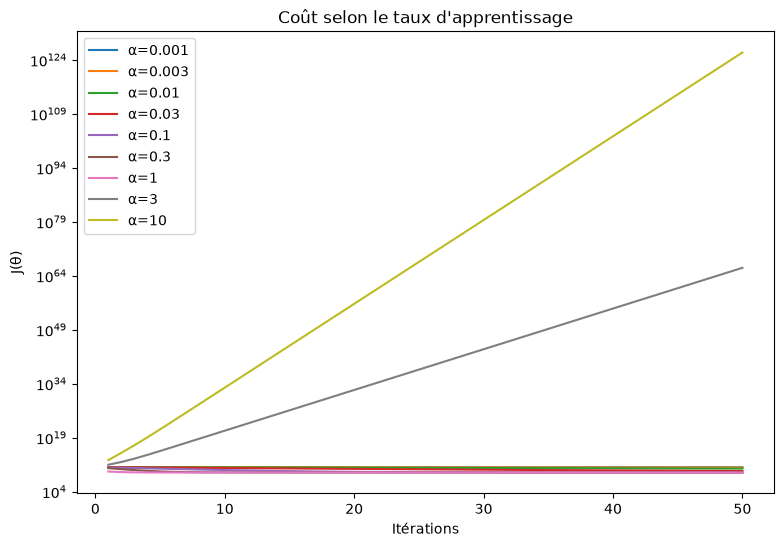

In [14]:
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1, 3, 10]
plt.figure(figsize=(9, 6))
for a in alphas:
    th = np.zeros((3, 1)); hist = []
    for k in range(50):
        th = iteration2(th, a)
        hist.append(J2(th))          # vecteur des valeurs de J
    plt.plot(range(1, 51), hist, label=f'α={a}')
    print(f'α={a:<6} J après 50 itérations = {hist[-1]:.4g}')
plt.yscale('log'); plt.xlabel('Itérations'); plt.ylabel('J(θ)'); plt.legend(); plt.title('Coût selon le taux d\'apprentissage'); plt.show()

**Réponse :** les $\alpha$ très petits (0,001 ; 0,003 ; 0,01) font décroître $J$ trop lentement ; les $\alpha$ trop grands ($\alpha\geq3$) font diverger l'algorithme ($J$ explose). Les valeurs $\alpha=0{,}3$ et $\alpha=1$ donnent la convergence la plus rapide : on retient **$\alpha=1$**.

In [15]:
alpha_opt = 1
theta_opt, n = descente(alpha_opt)
print('nombre d\'itérations :', n)
print('theta =', theta_opt.ravel(), ' J =', J2(theta_opt))

# vérification avec la solution exacte (équations normales)
print('solution exacte :', np.linalg.solve(X.T @ X, X.T @ Y).ravel())

nombre d'itérations : 22
theta = [340412.65957447 109447.48112602  -6578.33590045]  J = 2043280050.6493816
solution exacte : [340412.65957447 109447.79646964  -6578.35485416]


**Réponse :** avec $\alpha=1$, la convergence est atteinte en seulement 22 itérations (contre 320 avec $\alpha=0{,}07$), et $\theta$ coïncide avec la solution exacte des équations normales.

**Prédiction du prix d'un logement de 1650 m² et 3 pièces** : le nouveau point doit être normalisé avec le même `scaler` que les données d'apprentissage.

In [16]:
new = scaler.transform([[1650, 3]])
x_new = np.hstack([np.ones((1, 1)), new])
print(f'Prix prédit : {h_mat(theta_opt, x_new).item():.0f}')

Prix prédit : 293082


**Réponse :** le prix prédit pour un logement de 1650 m² et 3 pièces est d'environ **293 000** (293 082).